<a href="https://colab.research.google.com/github/chandrahashkumar/Machine_Learning/blob/master/MLLAB07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Experiment Number: 07**

Compute confusion matrices and F1-scores for a diabetes prediction model(Pima dataset)

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report

In [223]:
diabetes_df = pd.read_csv("diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [224]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [225]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

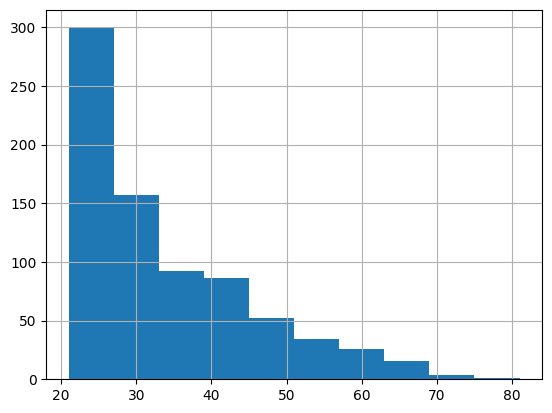

In [226]:
diabetes_df['Age'].hist()

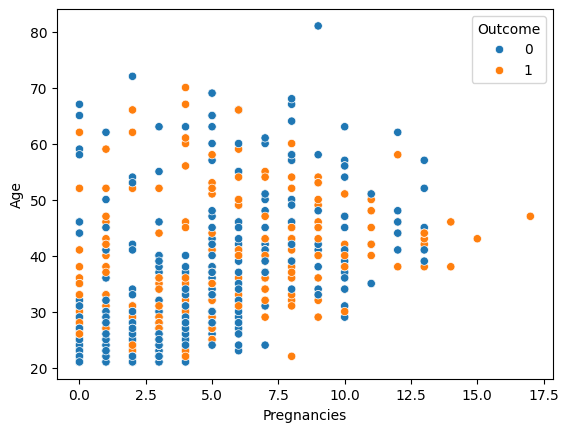

In [227]:
sns.scatterplot(data=diabetes_df, x='Pregnancies', y= 'Age', hue = 'Outcome')
plt.show()

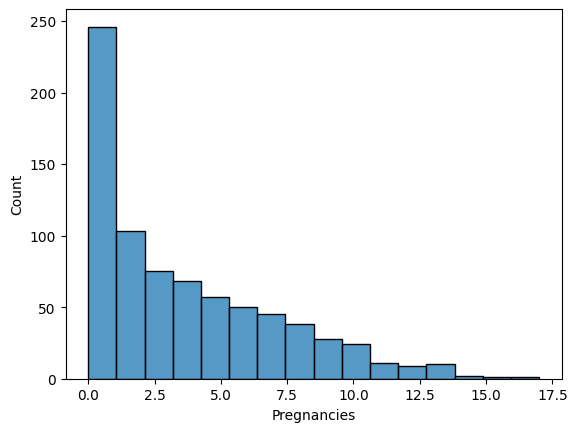

In [228]:
sns.histplot(data= diabetes_df, x = 'Pregnancies')
plt.show()

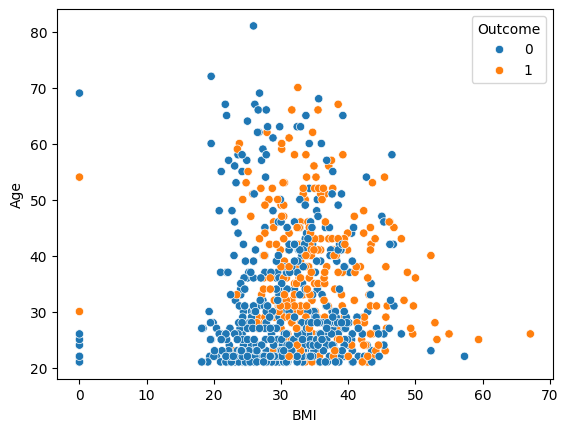

In [229]:
sns.scatterplot(data = diabetes_df, x = 'BMI', y = 'Age', hue = 'Outcome')
plt.show()

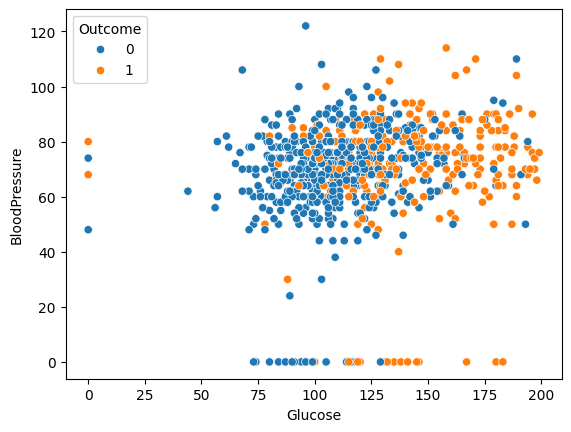

In [230]:
sns.scatterplot(data= diabetes_df, x = 'Glucose', y = 'BloodPressure', hue = 'Outcome')
plt.show()

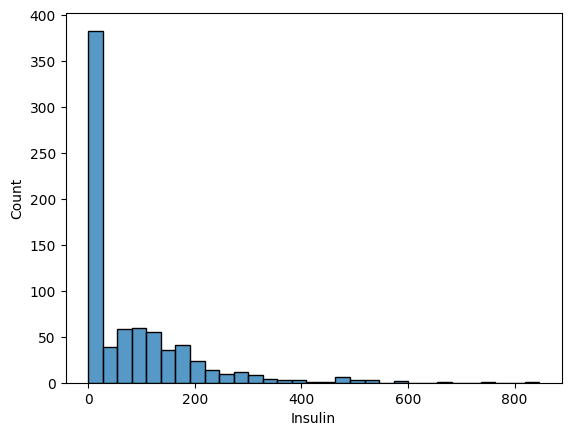

In [231]:
sns.histplot(data = diabetes_df, x = 'Insulin')
plt.show()

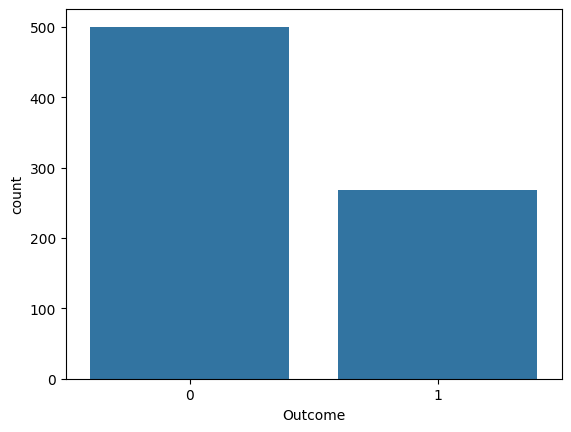

In [232]:
sns.countplot(data=diabetes_df, x='Outcome')
plt.show()

***Data Preprocessing***

In [233]:
df = diabetes_df[(diabetes_df['Insulin'] == 0) & (diabetes_df['Outcome'] == 0)]
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
10,4,110,92,0,0,37.6,0.191,30,0
12,10,139,80,0,0,27.1,1.441,57,0
...,...,...,...,...,...,...,...,...,...
756,7,137,90,41,0,32.0,0.391,39,0
758,1,106,76,0,0,37.5,0.197,26,0
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0


In [234]:
diabetes_df = diabetes_df[~diabetes_df.index.isin(df.index)]
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
...,...,...,...,...,...,...,...,...,...
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0
765,5,121,72,23,112,26.2,0.245,30,0


In [235]:
diabetes_df = diabetes_df[diabetes_df['BloodPressure'] != 0]
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
...,...,...,...,...,...,...,...,...,...
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0
765,5,121,72,23,112,26.2,0.245,30,0


In [236]:
diabetes_df = diabetes_df[diabetes_df['Glucose'] != 0]
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
...,...,...,...,...,...,...,...,...,...
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0
765,5,121,72,23,112,26.2,0.245,30,0


In [237]:
diabetes_df = diabetes_df[diabetes_df['SkinThickness'] != 0]
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
...,...,...,...,...,...,...,...,...,...
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0


In [238]:
diabetes_df[diabetes_df['BMI'] == 0.0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
371,0,118,64,23,89,0.0,1.731,21,0


In [239]:
mean_bmi = diabetes_df.loc[diabetes_df['BMI'] != 0, 'BMI'].mean()
print(mean_bmi)

33.39134396355353


In [240]:
diabetes_df.loc[371, 'BMI'] = mean_bmi
diabetes_df[diabetes_df['BMI'] == 0.0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


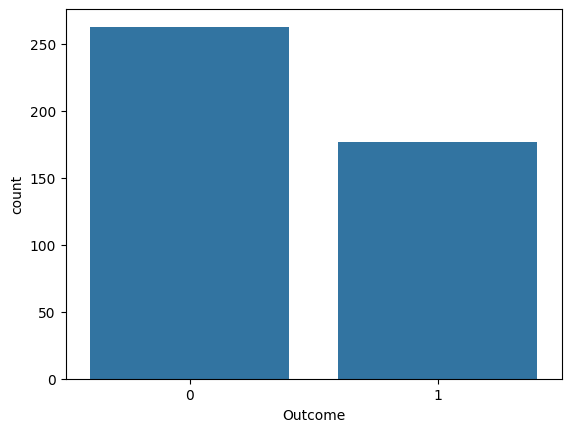

In [241]:
sns.countplot(data=diabetes_df, x='Outcome')
plt.show()

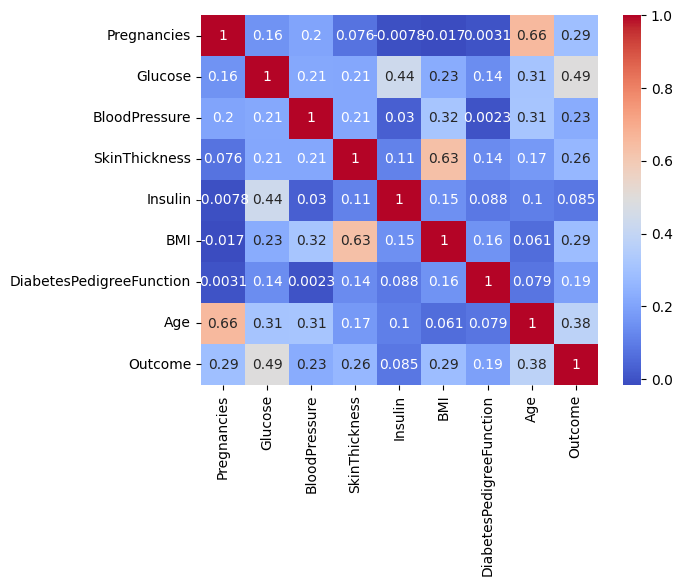

In [242]:
cr = diabetes_df.corr()
sns.heatmap(cr, annot= True, cmap= 'coolwarm')
plt.show()

***Training the classification model***

In [243]:
X = diabetes_df.drop(['Pregnancies','Outcome'], axis= 1)
y = diabetes_df['Outcome']

In [244]:
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148,72,35,0,33.6,0.627,50
3,89,66,23,94,28.1,0.167,21
4,137,40,35,168,43.1,2.288,33
6,78,50,32,88,31.0,0.248,26
8,197,70,45,543,30.5,0.158,53


In [245]:
 X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

In [246]:
logr = LogisticRegression()
logr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [247]:
yhat = logr.predict(X_test)

***Model Evaluation***

In [248]:
print(f"Model accuracy: {accuracy_score(y_test, yhat):.3f}")
print(f"F1 score: {100 * f1_score(y_test, yhat):.3f}")

Model accuracy: 0.659
F1 score: 55.882


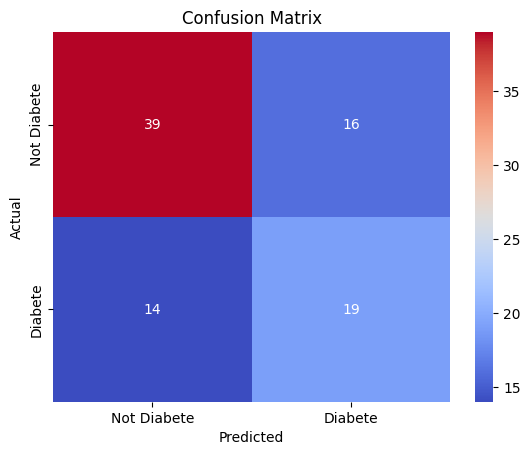

In [249]:
cm = confusion_matrix(y_test, yhat)
sns.heatmap(cm, annot= True, cmap = 'coolwarm', xticklabels= ['Not Diabete','Diabete'], yticklabels= ['Not Diabete','Diabete'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [250]:
print(f"Model Classification report:\n{classification_report(y_test, yhat)}")

Model Classification report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.72        55
           1       0.54      0.58      0.56        33

    accuracy                           0.66        88
   macro avg       0.64      0.64      0.64        88
weighted avg       0.66      0.66      0.66        88

